In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as si
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [2]:
def pendulo_doble(t,th_vth):
    g = 9.81
    # th_vth = [th1 , th2 , vth1 , vth2]
    dth1 = th_vth[2]
    dth2 = th_vth[3]
    d_th1th2 = th_vth[0]-th_vth[1]
    den = 3 -np.cos(2*d_th1th2)
    dvth1 = -3*g*np.sin(th_vth[0]) - g*np.sin(th_vth[0]-2*th_vth[1]) 
    -2*np.sin(d_th1th2)*(th_vth[3]**2 + th_vth[2]**2*np.cos(d_th1th2))
    dvth1 = dvth1/den
    dvth2 = 2*np.sin(d_th1th2)*(2*th_vth[2]**2 + 
                                2*g*np.cos(th_vth[0]) + th_vth[3]**2*np.cos(d_th1th2))
    dvth2 = dvth2/den
    return np.array([dth1,dth2,dvth1,dvth2])

def th2xy(th_vth):
    x1 = np.sin(th_vth[0])
    y1 = -np.cos(th_vth[0])
    x2 = x1 + np.sin(th_vth[1])
    y2 = y1 -np.cos(th_vth[1])
    return x1,y1,x2,y2

In [12]:
ci1 = [0.5*np.pi,0.5*np.pi,0,0]
ci2 = [0.5*np.pi,0.5*np.pi,0,1e-3]
titf = (0,100)
sol_pendulo1 = si.solve_ivp(pendulo_doble,titf,ci1,rtol=1e-8,atol=1e-10,
                        dense_output=True)
sol_pendulo2 = si.solve_ivp(pendulo_doble,titf,ci2,rtol=1e-8,atol=1e-10,
                        dense_output=True)
print(sol_pendulo1.success,sol_pendulo2.success)

True True


In [15]:
t = np.linspace(titf[0],titf[1],1000)
th_vth_1 = sol_pendulo1.sol(t)
pend1 = th2xy(th_vth_1)
th_vth_2 = sol_pendulo2.sol(t)
pend2 = th2xy(th_vth_2)

'\ndef cuadro(n):\n    fase_m1.set_data([th_vth[0,:n]],[th_vth[2,:n]])\n    fase_m2.set_data([th_vth[1,:n]],[th_vth[3,:n]]) \n    masa1.set_data([x1[n]],[y1[n]])\n    masa2.set_data([x2[n]],[y2[n]])\n    cuerda1.set_data([0,x1[n]],[0,y1[n]])\n    cuerda2.set_data([x1[n],x2[n]],[y1[n],y2[n]])\n    return fase_m1,fase_m2,masa1,masa2,cuerda1,cuerda2\n\nanimacion = FuncAnimation(figura,cuadro,frames=5, interval = 41,blit=True)\n\nplt.close()\n#HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video\nHTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video\n'

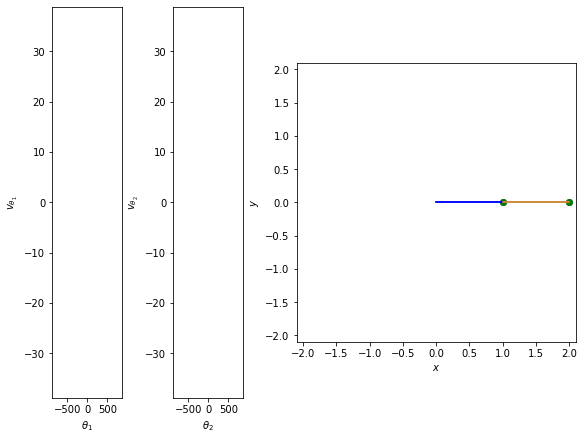

In [23]:
figura , ejes = plt.subplots(1,3,gridspec_kw= {'width_ratios':[1,1,4]},
                          layout="constrained",
                         figsize=(8,6))
#configuracion de la figura
mfx = max(abs(th_vth_1[0,:]).max(),abs(th_vth_1[1,:]).max(),
          abs(th_vth_2[0,:]).max(),abs(th_vth_2[1,:]).max())
mfy = max(abs(th_vth_1[2,:]).max(),abs(th_vth_1[3,:]).max(),
          abs(th_vth_2[2,:]).max(),abs(th_vth_2[3,:]).max())
ejes[0].set_xlabel(r'$\theta _1$'), ejes[0].set_ylabel(r'$v _{\theta _1}$')
ejes[1].set_xlabel(r'$\theta _2$'), ejes[1].set_ylabel(r'$v _{\theta _2}$')
ejes[2].set_xlabel(r'$x$'), ejes[2].set_ylabel(r'$y$')
ejes[0].set_xlim([-mfx,mfx]) , ejes[0].set_ylim([-mfy,mfy])
ejes[1].set_xlim([-mfx,mfx]) , ejes[1].set_ylim([-mfy,mfy])
ejes[2].set_xlim([-2.1,2.1]) , ejes[2].set_ylim([-2.1,2.1])
#ejes[0].set_aspect('equal')
#ejes[1].set_aspect('equal')
ejes[2].set_aspect('equal')
# Primer cuadro y variables iterables
fase_m1_1, = ejes[0].plot(th_vth_1[0,0],th_vth_1[2,0])
fase_m2_1, = ejes[1].plot(th_vth_1[1,0],th_vth_1[3,0])
fase_m1_2, = ejes[0].plot(th_vth_2[0,0],th_vth_2[2,0])
fase_m2_2, = ejes[1].plot(th_vth_2[1,0],th_vth_2[3,0])
masa1_1, = ejes[2].plot(pend1[0][0],pend1[1][0],'o',color='purple')
masa2_2, = ejes[2].plot(pend1[2][0],pend1[3][0],'o',color='purple')
masa1_2, = ejes[2].plot(pend2[0][0],pend2[1][0],'o',color='green')
masa2_2, = ejes[2].plot(pend2[2][0],pend2[3][0],'o',color='green')
cuerda1_1, = ejes[2].plot([0,pend1[0][0]],[0,pend1[1][0]],color='blue')
cuerda2_1, = ejes[2].plot( [pend1[0][0],pend1[2][0]] , [pend1[1][0],pend1[3][0]],color='blue')
cuerda1_2, = ejes[2].plot([0,pend2[0][0]],[0,pend2[1][0]],color='blue')
cuerda2_2, = ejes[2].plot( [pend2[0][0],pend2[2][0]] , [pend2[1][0],pend2[3][0]],color='orange')
"""
def cuadro(n):
    fase_m1.set_data([th_vth[0,:n]],[th_vth[2,:n]])
    fase_m2.set_data([th_vth[1,:n]],[th_vth[3,:n]]) 
    masa1.set_data([x1[n]],[y1[n]])
    masa2.set_data([x2[n]],[y2[n]])
    cuerda1.set_data([0,x1[n]],[0,y1[n]])
    cuerda2.set_data([x1[n],x2[n]],[y1[n],y2[n]])
    return fase_m1,fase_m2,masa1,masa2,cuerda1,cuerda2

animacion = FuncAnimation(figura,cuadro,frames=5, interval = 41,blit=True)

plt.close()
#HTML(animacion.to_html5_video()) # Usar esta linea si tengo compresor de video
HTML(animacion.to_jshtml()) # Usar esta linea si NO tengo compresor de video
"""